# Домашнее задание №3: «С этим товаром также покупают…»

**Студент:** Сизиков Константин.

**Цель**:
 - В этом задании вы продолжите работу с двухуровневой моделью, попробуете добавлять новые признаки, а также модели первого уровня, подберете гиперпараметры. В результате доработок качество модели, рассмотренной на занятии, должно улучшиться.


**Описание/Пошаговая инструкция выполнения домашнего задания**:
1. Продолжим работу с данными онлайн-кинотеатра KION.
2. Задача - улучшить качество двухуровневой модели, рассмотренной на занятии минимум на 10% по метрике precision@20. Для этого предлагается проделать хотя бы два из трех шагов:
 - добавить одну или несколько моделей первого уровня (можно брать модели из библиотеки implicit или других библиотек); на основе предсказаний этих моделей отобрать объекты-кандидаты для модели второго уровня;
 - фича-инжиниринг: поработать с имеющимися характеристиками пользователей и объектов и/или сгенерировать новые фичи на основе популярности объектов/активности пользователей; попробовать учесть временную составляющую, например, считать популярность за разные временные промежутки.
 - подобрать лучшее train-val-test разбиение; подобрать гиперпараметры моделей первого и второго уровней.
3. Оценить качество модели по метрикам precision@20, recall@20, mrr@20.
4. Написать отчет о проделанной работе: что удалось реализовать; что сработало/не сработало; что дало наибольший прирост качество; любые другие дополнения, относящиеся к проделанной работе.

In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'   # рекомендация implicit для CPU

import time
import warnings
import zipfile

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import implicit
from implicit.bpr import BayesianPersonalizedRanking
from implicit.als import AlternatingLeastSquares
from implicit.nearest_neighbours import CosineRecommender, TFIDFRecommender
from catboost import CatBoostClassifier
import lightgbm as lgb

warnings.simplefilter('ignore')
pd.set_option('display.max_columns', 50)
SEED = 42
N_JOBS = os.cpu_count()
print('implicit', implicit.__version__, '| lightgbm', lgb.__version__, '| pandas', pd.__version__)

implicit 0.7.3 | lightgbm 4.7.0 | pandas 3.0.6


## 1. Загрузка и предобработка данных


In [2]:
if not os.path.exists('data_kion/interactions_df.csv'):
    with zipfile.ZipFile('data_kion.zip') as z:
        z.extractall('.', members=[m for m in z.namelist() if not m.startswith('__MACOSX')])

interactions = pd.read_csv('data_kion/interactions_df.csv', parse_dates=['last_watch_dt'])
items = pd.read_csv('data_kion/items.csv')
users = pd.read_csv('data_kion/users.csv')

max_date = interactions['last_watch_dt'].max()
print('interactions:', interactions.shape, '| период:', interactions.last_watch_dt.min().date(), '—', max_date.date())

interactions: (5476251, 5) | период: 2021-03-13 — 2021-08-22


In [3]:
interactions = interactions[interactions['total_dur'] >= 300]
u_cnt = interactions.groupby('user_id').size()
interactions = interactions[interactions.user_id.isin(u_cnt[u_cnt >= 10].index)]
i_cnt = interactions.groupby('item_id').size()
interactions = interactions[interactions.item_id.isin(i_cnt[i_cnt >= 10].index)]
interactions['watched_pct'] = interactions['watched_pct'].fillna(0)
print('после фильтрации:', interactions.shape)

NU, NI = interactions.user_id.max() + 1, interactions.item_id.max() + 1

после фильтрации: (2300516, 5)


## 2. Разбиение на подвыборки
* `test` — последние 7 дней;
* `val` — 60 дней перед тестом, `train` — всё, что раньше.


In [4]:
test_thr = max_date - pd.Timedelta(days=7)
val_thr = test_thr - pd.Timedelta(days=60)

train = interactions[interactions.last_watch_dt < val_thr]
val = interactions[(interactions.last_watch_dt >= val_thr) & (interactions.last_watch_dt < test_thr)]
val = val[val.user_id.isin(train.user_id.unique())]
test = interactions[interactions.last_watch_dt >= test_thr]
test = test[test.user_id.isin(val.user_id.unique())]
test_users = test.user_id.unique()

print(f'train: {train.shape}, val: {val.shape}, test: {test.shape}, test users: {len(test_users)}')

train: (881660, 5), val: (694032, 5), test: (68028, 5), test users: 23195


## 3. Метрики
Реализация векторизована — на вход подаётся таблица `user_id, item_id, rank`. Ниже проверка, что результат совпадает с исходными функциями.

In [5]:
def metrics(true_df, pred_df, k=20):
    """true_df: user_id, item_id; pred_df: user_id, item_id, rank (ранги с 1)."""
    p = pred_df.loc[pred_df['rank'] <= k, ['user_id', 'item_id', 'rank']]
    hit = p.merge(true_df[['user_id', 'item_id']].drop_duplicates(), on=['user_id', 'item_id'])
    n_true = true_df.groupby('user_id').item_id.nunique()
    n_hit = hit.groupby('user_id').size().reindex(n_true.index, fill_value=0)
    rr = (1 / hit.groupby('user_id')['rank'].min()).reindex(n_true.index, fill_value=0)
    return {f'precision@{k}': (n_hit / np.minimum(k, n_true)).mean(),
            f'recall@{k}': (n_hit / n_true).mean(),
            f'mrr@{k}': rr.mean()}


# исходные функции для сверки
def precision_ref(df, pred_col='preds', true_col='item_id', k=30):
    return np.mean([len(set(r[true_col]) & set(r[pred_col][:k])) / min(k, len(r[true_col])) for _, r in df.iterrows()])

def recall_ref(df, pred_col='preds', true_col='item_id', k=30):
    return np.mean([len(set(r[true_col]) & set(r[pred_col][:k])) / len(r[true_col]) for _, r in df.iterrows()])

def mrr_ref(df, pred_col='preds', true_col='item_id', k=30):
    vals = []
    for _, r in df.iterrows():
        inter_ = set(r[true_col]) & set(r[pred_col][:k])
        vals.append(max([1 / (r[pred_col].index(i) + 1) for i in inter_], default=0))
    return np.mean(vals)

RESULTS = {}   # сводная таблица метрик на тесте

def report(name, pred_df, true_df=test, store=True):
    m = metrics(true_df, pred_df, k=20)
    if store:
        RESULTS[name] = m
    print(name, {k_: round(v, 4) for k_, v in m.items()})
    return m

## 4. Бейзлайн: BPR (train) → CatBoost (val)


In [6]:
def to_matrix(df, weight='watched_pct'):
    w = (df[weight].clip(lower=1).values / 100).astype(np.float32) if weight else np.ones(len(df), np.float32)
    return sp.csr_matrix((w, (df.user_id.values, df.item_id.values)), shape=(NU, NI))

def recommend(model, X, uids, N):
    ids, scores = model.recommend(uids, X[uids], N=N, filter_already_liked_items=True)
    out = pd.DataFrame({'user_id': np.repeat(uids, N), 'item_id': ids.ravel(), 'score': scores.ravel(),
                        'rank': np.tile(np.arange(1, N + 1), len(uids))})
    return out[(out.item_id >= 0) & (out.score > -1e30)]   # implicit дополняет короткие списки «пустыми» айтемами

In [7]:
t0 = time.time()
X_train = to_matrix(train)
bpr_base = BayesianPersonalizedRanking(factors=50, regularization=0.01, iterations=50, random_state=SEED)
bpr_base.fit(X_train, show_progress=False)

val_users = val.user_id.unique()
cand_base = recommend(bpr_base, X_train, val_users, 30)
cand_base['target'] = cand_base.merge(val[['user_id', 'item_id']].assign(t=1), how='left',
                                      on=['user_id', 'item_id'])['t'].fillna(0).values
pos = cand_base[cand_base.target == 1]
neg = cand_base[cand_base.target == 0].sample(len(pos) * 2, random_state=1)

tr_u, te_u = train_test_split(val_users, random_state=1, test_size=0.2)
tr_u, ev_u = train_test_split(tr_u, random_state=1, test_size=0.1)

base_user_col = ['user_id', 'age', 'income', 'sex', 'kids_flg']
base_item_col = ['item_id', 'content_type', 'countries', 'for_kids', 'age_rating', 'studios']
base_cat = ['age', 'income', 'sex', 'content_type', 'countries', 'studios']
base_feats = ['rank', 'age', 'income', 'sex', 'kids_flg', 'content_type', 'countries', 'for_kids', 'age_rating', 'studios']

def base_features(df):
    return df.merge(users[base_user_col], on='user_id', how='left').merge(items[base_item_col], on='item_id', how='left')

pn = pd.concat([pos, neg])
base_tr = base_features(pn[pn.user_id.isin(tr_u)])
base_ev = base_features(pn[pn.user_id.isin(ev_u)])
fill_mode = base_tr[base_feats].mode().iloc[0]

ctb_base = CatBoostClassifier(subsample=0.9, max_depth=5, n_estimators=2000, learning_rate=0.01,
                              thread_count=N_JOBS, random_state=SEED, verbose=0)
ctb_base.fit(base_tr[base_feats].fillna(fill_mode), base_tr.target,
             eval_set=(base_ev[base_feats].fillna(fill_mode), base_ev.target),
             early_stopping_rounds=100, cat_features=base_cat)

# предсказание на тесте: BPR (обученный на train) даёт top-100, CatBoost переранжирует
pred_bpr_test = recommend(bpr_base, X_train, test_users, 100)
report('baseline: BPR (train)', pred_bpr_test)
sc = base_features(pred_bpr_test)
pred_bpr_test = pred_bpr_test.assign(p=ctb_base.predict_proba(sc[base_feats].fillna(fill_mode))[:, 1])
pred_bpr_test = pred_bpr_test.sort_values(['user_id', 'p'], ascending=[True, False])
pred_bpr_test['rank'] = pred_bpr_test.groupby('user_id').cumcount() + 1
report('baseline: BPR + CatBoost', pred_bpr_test)
print(f'{time.time() - t0:.0f} s')

baseline: BPR (train) {'precision@20': np.float64(0.0464), 'recall@20': np.float64(0.0463), 'mrr@20': np.float64(0.0272)}


baseline: BPR + CatBoost {'precision@20': np.float64(0.0607), 'recall@20': np.float64(0.0607), 'mrr@20': np.float64(0.0396)}
53 s


Сверка векторизованных метрик с исходными функциями на 3000 пользователях:

In [8]:
chk_users = test_users[:3000]
true_lists = test[test.user_id.isin(chk_users)].groupby('user_id').item_id.agg(list).rename('item_id')
pred_lists = pred_bpr_test[pred_bpr_test.user_id.isin(chk_users)].sort_values(['user_id', 'rank']) \
    .groupby('user_id').item_id.agg(list).rename('preds')
chk = pd.concat([true_lists, pred_lists], axis=1).reset_index()
print('ref :', round(precision_ref(chk, k=20), 6), round(recall_ref(chk, k=20), 6), round(mrr_ref(chk, k=20), 6))
print('ours:', {k_: round(v, 6) for k_, v in metrics(test[test.user_id.isin(chk_users)],
                                                    pred_bpr_test[pred_bpr_test.user_id.isin(chk_users)]).items()})

ref : 0.050073 0.049727 0.051553
ours: {'precision@20': np.float64(0.050073), 'recall@20': np.float64(0.049727), 'mrr@20': np.float64(0.051553)}


**Главная слабость бейзлайна:** BPR обучен только на `train` (до середины июня), а тест — конец августа. Модель не знает о двух
месяцах истории (`val`) и о новинках, а фильтр «уже просмотренного» не учитывает просмотры из `val`.
Кроме того, в KION очень сильный эффект популярности/новинок, а BPR его почти не ловит.

## 5. Модели первого уровня
Все модели первого уровня на этапе предсказания обучаются на **всей истории до момента предсказания** `T`.
Рассматриваем:
* `pop` — топ популярного за последние 7 дней (без уже просмотренного);
* `tfidf`, `cos` — item-kNN из `implicit` (бинарная матрица, K=100);
* `bpr`, `als` — матричные разложения из `implicit` (веса — `watched_pct`).

In [9]:
FIRST_LEVEL = {
    #  имя      конструктор модели                                                                                   веса          топ-N
    'tfidf': (lambda: TFIDFRecommender(K=100),                                                                       None,         100),
    'cos':   (lambda: CosineRecommender(K=100),                                                                      None,         50),
    'bpr':   (lambda: BayesianPersonalizedRanking(factors=64, regularization=0.01, iterations=50, random_state=SEED), 'watched_pct', 50),
    'als':   (lambda: AlternatingLeastSquares(factors=64, regularization=0.05, iterations=15, random_state=SEED),     'watched_pct', 50),
}
N_POP = 100
SOURCES = ['pop'] + list(FIRST_LEVEL)


def popular_candidates(hist, uids, T, days=7, N=N_POP):
    vc = hist[hist.last_watch_dt >= T - pd.Timedelta(days=days)].item_id.value_counts()
    top = vc.index[:N + 200].values
    c = pd.DataFrame({'user_id': np.repeat(uids, len(top)), 'item_id': np.tile(top, len(uids))})
    seen = hist.loc[hist.user_id.isin(uids), ['user_id', 'item_id']].assign(seen=1)
    c = c.merge(seen, how='left', on=['user_id', 'item_id'])
    c = c[c.seen.isna()].drop(columns='seen')
    c['rank'] = c.groupby('user_id').cumcount() + 1
    c = c[c['rank'] <= N]
    c['score'] = vc.reindex(c.item_id).values
    return c


def generate_candidates(hist, uids, T):
    """Объединение кандидатов всех моделей первого уровня; ранги и скоры каждой модели — отдельные столбцы."""
    parts = [popular_candidates(hist, uids, T).assign(src='pop')]
    matrices = {}
    for name, (make_model, weight, N) in FIRST_LEVEL.items():
        if weight not in matrices:
            matrices[weight] = to_matrix(hist, weight)
        model = make_model()
        model.fit(matrices[weight], show_progress=False)
        parts.append(recommend(model, matrices[weight], uids, N).assign(src=name))
    cand = pd.concat(parts).pivot_table(index=['user_id', 'item_id'], columns='src',
                                        values=['rank', 'score'], aggfunc='first')
    cand.columns = [f'{src}_{val_}' for val_, src in cand.columns]
    cand = cand.reset_index()
    for s in SOURCES:
        cand[f'{s}_rank'] = cand[f'{s}_rank'].fillna(999)
    cand['n_src'] = (cand[[f'{s}_rank' for s in SOURCES]] < 999).sum(axis=1)
    return cand

In [10]:
t0 = time.time()
hist_test = interactions[interactions.last_watch_dt < test_thr]      # вся история до теста = train + val
cand_test = generate_candidates(hist_test, test_users, test_thr)
print(f'кандидатов: {len(cand_test):,} ({len(cand_test) / len(test_users):.0f} на пользователя), {time.time() - t0:.0f} s')

for s in SOURCES:
    single = cand_test.loc[cand_test[f'{s}_rank'] < 999, ['user_id', 'item_id', f'{s}_rank']] \
        .rename(columns={f'{s}_rank': 'rank'})
    report(f'1-й уровень: {s} (train+val)', single)

test_pairs = test[['user_id', 'item_id']].drop_duplicates()
cov = cand_test.merge(test_pairs, on=['user_id', 'item_id']).shape[0] / len(test_pairs)
print(f'\nполнота пула кандидатов (доля тестовых просмотров, попавших в кандидаты): {cov:.3f}')

кандидатов: 5,018,142 (216 на пользователя), 19 s
1-й уровень: pop (train+val) {'precision@20': np.float64(0.1945), 'recall@20': np.float64(0.1944), 'mrr@20': np.float64(0.1316)}
1-й уровень: tfidf (train+val) {'precision@20': np.float64(0.1853), 'recall@20': np.float64(0.1852), 'mrr@20': np.float64(0.1328)}
1-й уровень: cos (train+val) {'precision@20': np.float64(0.1835), 'recall@20': np.float64(0.1834), 'mrr@20': np.float64(0.1324)}
1-й уровень: bpr (train+val) {'precision@20': np.float64(0.0969), 'recall@20': np.float64(0.0969), 'mrr@20': np.float64(0.0621)}


1-й уровень: als (train+val) {'precision@20': np.float64(0.093), 'recall@20': np.float64(0.0929), 'mrr@20': np.float64(0.0551)}

полнота пула кандидатов (доля тестовых просмотров, попавших в кандидаты): 0.477


Уже на первом уровне видно главное: **переобучение на всей истории** (BPR: \~0.05 → \~0.10) и **популярность за последнюю
неделю/item-kNN** (\~0.18–0.19) сильнее всего бейзлайна. Модели дополняют друг друга: объединённый пул кандидатов покрывает
заметно больше тестовых просмотров, чем любая модель в отдельности. Задача второго уровня — правильно смешать эти источники.

## 6. Признаки для модели второго уровня
Все признаки считаются **только по истории до момента `T`** (для обучения ранкера — до начала окна меток, для теста — до `test_thr`),
поэтому утечки из будущего нет.

| группа | признаки |
|---|---|
| первый уровень | `{pop,tfidf,cos,bpr,als}_rank`, `*_score`, `n_src` — число моделей, предложивших айтем |
| популярность айтема | `i_pop1/3/7/14/30` — число просмотров за последние N дней, `i_pop_all`, `i_trend = pop7 / (pop30/4)` |
| статистики айтема | `i_wpct` — средний % досмотра, `i_age_days` — дней с первого просмотра (новизна), `i_dur` — медианная длительность |
| контент айтема | `content_type`, `release_year`, `for_kids`, `age_rating`, `countries`, `studios`, `genre1` |
| активность пользователя | `u_n`, `u_n7`, `u_n30`, `u_last` — дней с последнего просмотра, `u_tenure`, `u_wpct`, `u_dur` |
| пользователь × айтем | `u_series_share`, `ct_match` — склонность к типу контента, `ug_mean/ug_max` — доля жанров айтема в истории пользователя |
| соцдем | `age`, `income`, `sex`, `kids_flg` |

In [11]:
ITEM_STATIC = items[['item_id', 'content_type', 'release_year', 'for_kids', 'age_rating', 'countries', 'studios']].copy()
ITEM_STATIC['genre1'] = items.genres.str.split(', ').str[0]
ITEM_GENRES = items[['item_id', 'genres']].dropna().assign(g=lambda x: x.genres.str.split(', ')).explode('g')[['item_id', 'g']]
CAT_FEATURES = ['content_type', 'countries', 'studios', 'genre1', 'age', 'income', 'sex']


def add_features(c, hist, T):
    c = c.copy()
    # --- популярность айтема за разные окна
    for days in [1, 3, 7, 14, 30]:
        vc = hist[hist.last_watch_dt >= T - pd.Timedelta(days=days)].item_id.value_counts()
        c[f'i_pop{days}'] = vc.reindex(c.item_id).fillna(0).values
    c['i_pop_all'] = hist.item_id.value_counts().reindex(c.item_id).fillna(0).values
    c['i_trend'] = (c.i_pop7 + 1) / (c.i_pop30 / 4 + 1)
    # --- статистики айтема
    g = hist.groupby('item_id')
    i_stat = pd.DataFrame({'i_wpct': g.watched_pct.mean(),
                           'i_age_days': (T - g.last_watch_dt.min()).dt.days,
                           'i_dur': g.total_dur.median()})
    c = c.merge(i_stat, how='left', left_on='item_id', right_index=True)
    # --- активность пользователя
    hu = hist[hist.user_id.isin(c.user_id.unique())]
    g = hu.groupby('user_id')
    u_stat = pd.DataFrame({'u_n': g.size(), 'u_wpct': g.watched_pct.mean(),
                           'u_last': (T - g.last_watch_dt.max()).dt.days,
                           'u_tenure': (T - g.last_watch_dt.min()).dt.days,
                           'u_dur': g.total_dur.mean()})
    for days in [7, 30]:
        u_stat[f'u_n{days}'] = hu[hu.last_watch_dt >= T - pd.Timedelta(days=days)].groupby('user_id').size() \
            .reindex(u_stat.index).fillna(0)
    hu_ct = hu[['user_id', 'item_id']].merge(ITEM_STATIC[['item_id', 'content_type']], on='item_id', how='left')
    u_stat['u_series_share'] = (hu_ct.content_type == 'series').groupby(hu_ct.user_id).mean().reindex(u_stat.index)
    c = c.merge(u_stat, how='left', left_on='user_id', right_index=True)
    # --- жанровая близость: доля жанров айтема в истории пользователя
    ug = hu[['user_id', 'item_id']].merge(ITEM_GENRES, on='item_id').groupby(['user_id', 'g']).size().rename('cnt').reset_index()
    ug['share'] = ug.cnt / ug.user_id.map(u_stat.u_n)
    cg = c[['user_id', 'item_id']].merge(ITEM_GENRES, on='item_id') \
        .merge(ug[['user_id', 'g', 'share']], on=['user_id', 'g'], how='left').fillna({'share': 0})
    ga = cg.groupby(['user_id', 'item_id']).share.agg(ug_mean='mean', ug_max='max').reset_index()
    c = c.merge(ga, how='left', on=['user_id', 'item_id'])
    # --- статические признаки
    c = c.merge(ITEM_STATIC, how='left', on='item_id')
    c = c.merge(users[['user_id', 'age', 'income', 'sex', 'kids_flg']], how='left', on='user_id')
    c['ct_match'] = np.where(c.content_type == 'series', c.u_series_share, 1 - c.u_series_share)
    for col in CAT_FEATURES:
        c[col] = c[col].fillna('NA').astype(str)
    return c

## 7. Обучающая выборка для ранкера
Схема для момента предсказания `T` и окна меток длины `W`:
* модели первого уровня обучаются на истории `< T − W` и генерируют кандидатов;
* метка `target = 1`, если пользователь посмотрел кандидата в окне `[T − W, T)`;
* берём пользователей, у которых есть хотя бы один положительный кандидат, негативы сэмплируем (25%);
* признаки считаются по истории `< T − W`.

После обучения ранкер применяется к кандидатам, построенным по всей истории `< T`.

In [12]:
def build_train_set(T, window, n_users=60000, neg_frac=0.25, seed=0):
    T_lbl = T - pd.Timedelta(days=window)
    hist = interactions[interactions.last_watch_dt < T_lbl]
    labels = interactions[(interactions.last_watch_dt >= T_lbl) & (interactions.last_watch_dt < T)]
    labels = labels[labels.user_id.isin(hist.user_id.unique())]
    rng = np.random.default_rng(seed)
    uids = labels.user_id.unique()
    uids = rng.choice(uids, min(n_users, len(uids)), replace=False)
    c = generate_candidates(hist, uids, T_lbl)
    c = c.merge(labels[['user_id', 'item_id']].drop_duplicates().assign(target=1), how='left', on=['user_id', 'item_id'])
    c['target'] = c.target.fillna(0).astype(int)
    has_pos = c.groupby('user_id').target.transform('max') > 0
    c = c[has_pos]
    c = pd.concat([c[c.target == 1], c[c.target == 0].sample(frac=neg_frac, random_state=seed)])
    c = add_features(c, hist, T_lbl).sort_values('user_id').reset_index(drop=True)
    return c


def to_lgb(df, feats):
    X = df[feats].copy()
    for col in CAT_FEATURES:
        if col in X:
            X[col] = pd.Categorical(X[col], categories=CATEGORIES[col])
    return X

# словарь категорий фиксируем по всем айтемам/пользователям, чтобы коды совпадали в train и test
CATEGORIES = {col: pd.Index(sorted(set(ITEM_STATIC[col].fillna('NA').astype(str)) | {'NA'}))
              for col in ['content_type', 'countries', 'studios', 'genre1']}
CATEGORIES.update({col: pd.Index(sorted(set(users[col].fillna('NA').astype(str)) | {'NA'})) for col in ['age', 'income', 'sex']})

LGB_DEFAULT = dict(n_estimators=3000, learning_rate=0.03, num_leaves=63, min_child_samples=50, subsample=0.8, subsample_freq=1,
                   colsample_bytree=0.8, max_cat_to_onehot=8, cat_l2=10, n_jobs=N_JOBS, random_state=SEED, verbose=-1)


def fit_lgb_ranker(train_df, feats, params=None, seed=0):
    """LambdaRank; 10% пользователей уходят в eval для early stopping."""
    params = {**LGB_DEFAULT, **(params or {})}
    uu = train_df.user_id.unique()
    ev_users = np.random.default_rng(seed).choice(uu, len(uu) // 10, replace=False)
    is_ev = train_df.user_id.isin(ev_users)
    tr, ev = train_df[~is_ev], train_df[is_ev]
    group = lambda d: d.groupby('user_id', sort=False).size().values
    model = lgb.LGBMRanker(**params)
    model.fit(to_lgb(tr, feats), tr.target, group=group(tr),
              eval_set=[(to_lgb(ev, feats), ev.target)], eval_group=[group(ev)], eval_at=[20],
              callbacks=[lgb.early_stopping(200, verbose=False)])
    return model


def rerank(cand, scores):
    r = cand[['user_id', 'item_id']].assign(p=scores).sort_values(['user_id', 'p'], ascending=[True, False])
    r['rank'] = r.groupby('user_id').cumcount() + 1
    return r

## 8. Подбор окна меток и гиперпараметров на валидационной неделе
Чтобы не подбирать параметры на тесте, вводим **валидационную неделю** `[test_thr − 7, test_thr)`: она играет роль теста,
а ранкер для неё обучается на метках из более раннего окна. Оцениваем на 20 000 тёплых пользователей этой недели.

In [13]:
T_val = test_thr - pd.Timedelta(days=7)
hist_val = interactions[interactions.last_watch_dt < T_val]
holdout = interactions[(interactions.last_watch_dt >= T_val) & (interactions.last_watch_dt < test_thr)]
holdout = holdout[holdout.user_id.isin(hist_val.user_id.unique())]
holdout_users = np.random.default_rng(1).choice(holdout.user_id.unique(), 20000, replace=False)
holdout = holdout[holdout.user_id.isin(holdout_users)]

t0 = time.time()
cand_val = add_features(generate_candidates(hist_val, holdout_users, T_val), hist_val, T_val)
FEATURES = [c for c in cand_val.columns if c not in ('user_id', 'item_id')]
print(f'признаков: {len(FEATURES)}, кандидатов на валидации: {len(cand_val):,}, {time.time() - t0:.0f} s')

признаков: 43, кандидатов на валидации: 4,274,484, 21 s


In [14]:
val_results = []
train_sets_val = {}
for window in [7, 14, 21]:
    t0 = time.time()
    train_sets_val[window] = build_train_set(T_val, window)
    model = fit_lgb_ranker(train_sets_val[window], FEATURES)
    m = metrics(holdout, rerank(cand_val, model.predict(to_lgb(cand_val, FEATURES))))
    val_results.append({'window': window, 'num_leaves': LGB_DEFAULT['num_leaves'], 'best_iter': model.best_iteration_, **m})
    print(window, {k_: round(v, 4) for k_, v in m.items()}, f'{time.time() - t0:.0f} s')

best_window = max(val_results, key=lambda r: r['precision@20'])['window']
print('лучшее окно меток:', best_window)

7 {'precision@20': np.float64(0.2397), 'recall@20': np.float64(0.2396), 'mrr@20': np.float64(0.1794)} 99 s


14 {'precision@20': np.float64(0.2431), 'recall@20': np.float64(0.243), 'mrr@20': np.float64(0.1774)} 118 s


21 {'precision@20': np.float64(0.2392), 'recall@20': np.float64(0.2391), 'mrr@20': np.float64(0.1759)} 138 s
лучшее окно меток: 14


In [15]:
for num_leaves, min_child in [(31, 100), (127, 50), (255, 100)]:
    t0 = time.time()
    model = fit_lgb_ranker(train_sets_val[best_window], FEATURES, dict(num_leaves=num_leaves, min_child_samples=min_child))
    m = metrics(holdout, rerank(cand_val, model.predict(to_lgb(cand_val, FEATURES))))
    val_results.append({'window': best_window, 'num_leaves': num_leaves, 'min_child_samples': min_child,
                        'best_iter': model.best_iteration_, **m})
    print(num_leaves, min_child, {k_: round(v, 4) for k_, v in m.items()}, f'{time.time() - t0:.0f} s')

val_results = pd.DataFrame(val_results).fillna({'min_child_samples': LGB_DEFAULT['min_child_samples']})
best = val_results[val_results.window == best_window].sort_values('precision@20', ascending=False).iloc[0]
BEST_PARAMS = dict(num_leaves=int(best.num_leaves), min_child_samples=int(best.min_child_samples))
print('лучшие параметры:', BEST_PARAMS)
val_results.round(4)

31 100 {'precision@20': np.float64(0.2429), 'recall@20': np.float64(0.2427), 'mrr@20': np.float64(0.1776)} 129 s


127 50 {'precision@20': np.float64(0.2423), 'recall@20': np.float64(0.2422), 'mrr@20': np.float64(0.1768)} 94 s


255 100 {'precision@20': np.float64(0.2406), 'recall@20': np.float64(0.2405), 'mrr@20': np.float64(0.1749)} 74 s
лучшие параметры: {'num_leaves': 63, 'min_child_samples': 50}


,window,num_leaves,best_iter,precision@20,recall@20,mrr@20,min_child_samples
0,7,63,721,0.2397,0.2396,0.1794,50.0
1,14,63,572,0.2431,0.2430,0.1774,50.0
2,21,63,683,0.2392,0.2391,0.1759,50.0
3,14,31,1331,0.2429,0.2427,0.1776,100.0
4,14,127,570,0.2423,0.2422,0.1768,50.0
5,14,255,280,0.2406,0.2405,0.1749,100.0


In [16]:
# одиночные модели первого уровня на валидационной неделе — для сравнения
for s in SOURCES:
    single = cand_val.loc[cand_val[f'{s}_rank'] < 999, ['user_id', 'item_id', f'{s}_rank']].rename(columns={f'{s}_rank': 'rank'})
    print(s, {k_: round(v, 4) for k_, v in metrics(holdout, single).items()})

pop {'precision@20': np.float64(0.1789), 'recall@20': np.float64(0.1789), 'mrr@20': np.float64(0.1299)}
tfidf {'precision@20': np.float64(0.1926), 'recall@20': np.float64(0.1925), 'mrr@20': np.float64(0.144)}
cos {'precision@20': np.float64(0.1909), 'recall@20': np.float64(0.1908), 'mrr@20': np.float64(0.144)}
bpr {'precision@20': np.float64(0.1136), 'recall@20': np.float64(0.1135), 'mrr@20': np.float64(0.0907)}
als {'precision@20': np.float64(0.0994), 'recall@20': np.float64(0.0994), 'mrr@20': np.float64(0.0696)}


## 9. Финальная модель и оценка на тесте
Ранкер обучается на окне меток `[test_thr − W, test_thr)` с подобранными `W` и гиперпараметрами,
затем переранжирует кандидатов, построенных по всей истории до `test_thr`.

In [17]:
t0 = time.time()
train_set = build_train_set(test_thr, best_window)
print(f'обучающая выборка ранкера: {train_set.shape}, доля позитивов {train_set.target.mean():.3f}, '
      f'пользователей {train_set.user_id.nunique()}, {time.time() - t0:.0f} s')

cand_test = add_features(cand_test, hist_test, test_thr)

t0 = time.time()
lgb_final = fit_lgb_ranker(train_set, FEATURES, BEST_PARAMS)
pred_lgb = rerank(cand_test, lgb_final.predict(to_lgb(cand_test, FEATURES)))
print(f'best iteration: {lgb_final.best_iteration_}, {time.time() - t0:.0f} s')
report('2 уровня: 5 моделей 1-го уровня + LightGBM LambdaRank', pred_lgb);

обучающая выборка ранкера: (2526776, 46), доля позитивов 0.051, пользователей 45955, 38 s


best iteration: 822, 112 s
2 уровня: 5 моделей 1-го уровня + LightGBM LambdaRank {'precision@20': np.float64(0.243), 'recall@20': np.float64(0.2429), 'mrr@20': np.float64(0.1647)}


Для сравнения — CatBoostClassifier

In [18]:
t0 = time.time()
uu = train_set.user_id.unique()
ev_users = np.random.default_rng(0).choice(uu, len(uu) // 10, replace=False)
is_ev = train_set.user_id.isin(ev_users)
ctb_final = CatBoostClassifier(iterations=1500, learning_rate=0.1, depth=6, eval_metric='AUC',
                               thread_count=N_JOBS, random_seed=SEED, verbose=0)
ctb_final.fit(train_set.loc[~is_ev, FEATURES], train_set.loc[~is_ev, 'target'],
              eval_set=(train_set.loc[is_ev, FEATURES], train_set.loc[is_ev, 'target']),
              cat_features=CAT_FEATURES, early_stopping_rounds=100)
p_ctb = ctb_final.predict_proba(cand_test[FEATURES])[:, 1]
pred_ctb = rerank(cand_test, p_ctb)
print(f'best iteration: {ctb_final.get_best_iteration()}, {time.time() - t0:.0f} s')
report('2 уровня: 5 моделей 1-го уровня + CatBoostClassifier', pred_ctb)

# простой ансамбль: среднее нормированных рангов двух ранкеров
p_lgb = lgb_final.predict(to_lgb(cand_test, FEATURES))
blend = pd.Series(p_lgb).rank(pct=True).values + pd.Series(p_ctb).rank(pct=True).values
report('2 уровня: ансамбль LightGBM + CatBoost', rerank(cand_test, blend));

best iteration: 1468, 1119 s
2 уровня: 5 моделей 1-го уровня + CatBoostClassifier {'precision@20': np.float64(0.2454), 'recall@20': np.float64(0.2453), 'mrr@20': np.float64(0.1682)}


2 уровня: ансамбль LightGBM + CatBoost {'precision@20': np.float64(0.2457), 'recall@20': np.float64(0.2456), 'mrr@20': np.float64(0.1677)}


### Важность признаков (LightGBM, gain)

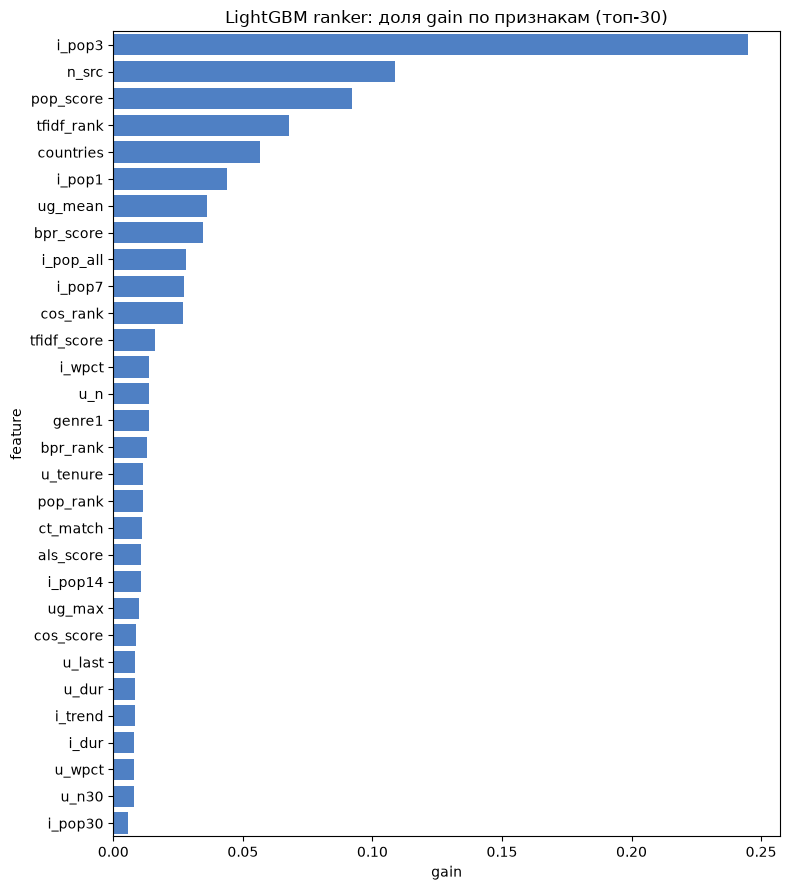

In [19]:
imp = pd.DataFrame({'feature': FEATURES, 'gain': lgb_final.booster_.feature_importance('gain')})
imp['gain'] = imp.gain / imp.gain.sum()
plt.figure(figsize=(8, 9))
sns.barplot(data=imp.sort_values('gain', ascending=False).head(30), x='gain', y='feature', color='#3b7dd8')
plt.title('LightGBM ranker: доля gain по признакам (топ-30)')
plt.tight_layout()
plt.show()

## 10. Абляция: что дало прирост
Переобучаем ранкер (те же данные и параметры) на подмножествах признаков, а также убираем источники кандидатов.

In [20]:
FL_FEATS = [f for f in FEATURES if f.split('_')[0] in SOURCES] + ['n_src']
POP_FEATS = [f for f in FEATURES if f.startswith('i_pop') or f == 'i_trend']
ablations = {
    'только признаки 1-го уровня (ранги/скоры)': FL_FEATS,
    '1-й уровень + популярность айтема': FL_FEATS + POP_FEATS,
    'все признаки без признаков 1-го уровня': [f for f in FEATURES if f not in FL_FEATS],
    'все признаки без пользователь×айтем (жанры, тип)': [f for f in FEATURES if f not in ('ug_mean', 'ug_max', 'ct_match', 'u_series_share')],
}
abl_rows = []
for name, feats in ablations.items():
    m = fit_lgb_ranker(train_set, feats, BEST_PARAMS)
    res = report(f'абляция: {name}', rerank(cand_test, m.predict(to_lgb(cand_test, feats))), store=False)
    abl_rows.append({'вариант': name, 'число признаков': len(feats), **res})

# убираем источник кандидатов: строки, найденные только им, и его признаки
for src in SOURCES:
    keep_tr = (train_set[[f'{s}_rank' for s in SOURCES if s != src]] < 999).any(axis=1)
    keep_te = (cand_test[[f'{s}_rank' for s in SOURCES if s != src]] < 999).any(axis=1)
    feats = [f for f in FEATURES if not f.startswith(src + '_')]
    m = fit_lgb_ranker(train_set[keep_tr], feats, BEST_PARAMS)
    res = report(f'абляция: без кандидатов {src}', rerank(cand_test[keep_te], m.predict(to_lgb(cand_test[keep_te], feats))), store=False)
    abl_rows.append({'вариант': f'без источника кандидатов {src}', 'число признаков': len(feats), **res})

pd.DataFrame(abl_rows).round(4)

абляция: только признаки 1-го уровня (ранги/скоры) {'precision@20': np.float64(0.2183), 'recall@20': np.float64(0.2182), 'mrr@20': np.float64(0.1251)}


абляция: 1-й уровень + популярность айтема {'precision@20': np.float64(0.2413), 'recall@20': np.float64(0.2412), 'mrr@20': np.float64(0.1621)}


абляция: все признаки без признаков 1-го уровня {'precision@20': np.float64(0.2144), 'recall@20': np.float64(0.2143), 'mrr@20': np.float64(0.1432)}


абляция: все признаки без пользователь×айтем (жанры, тип) {'precision@20': np.float64(0.2464), 'recall@20': np.float64(0.2463), 'mrr@20': np.float64(0.1653)}


абляция: без кандидатов pop {'precision@20': np.float64(0.2364), 'recall@20': np.float64(0.2363), 'mrr@20': np.float64(0.165)}


абляция: без кандидатов tfidf {'precision@20': np.float64(0.2388), 'recall@20': np.float64(0.2387), 'mrr@20': np.float64(0.1648)}


абляция: без кандидатов cos {'precision@20': np.float64(0.2426), 'recall@20': np.float64(0.2425), 'mrr@20': np.float64(0.1671)}


абляция: без кандидатов bpr {'precision@20': np.float64(0.2424), 'recall@20': np.float64(0.2423), 'mrr@20': np.float64(0.1635)}


абляция: без кандидатов als {'precision@20': np.float64(0.2423), 'recall@20': np.float64(0.2422), 'mrr@20': np.float64(0.1652)}


,вариант,число признаков,precision@20,recall@20,mrr@20
0,только признаки 1-го уровня (ранги/скоры),11,0.2183,0.2182,0.1251
1,1-й уровень + популярность айтема,18,0.2413,0.2412,0.1621
2,все признаки без признаков 1-го уровня,32,0.2144,0.2143,0.1432
3,"все признаки без пользователь×айтем (жанры, тип)",39,0.2464,0.2463,0.1653
4,без источника кандидатов pop,41,0.2364,0.2363,0.1650
5,без источника кандидатов tfidf,41,0.2388,0.2387,0.1648
6,без источника кандидатов cos,41,0.2426,0.2425,0.1671
7,без источника кандидатов bpr,41,0.2424,0.2423,0.1635
8,без источника кандидатов als,41,0.2423,0.2422,0.1652


## 11. Итоговая таблица на тесте

In [21]:
summary = pd.DataFrame(RESULTS).T
base_p = summary.loc['baseline: BPR + CatBoost', 'precision@20']
summary['прирост precision@20 к бейзлайну'] = (summary['precision@20'] / base_p - 1).map(lambda x: f'{x:+.0%}')
summary.round(4)

,precision@20,recall@20,mrr@20,прирост precision@20 к бейзлайну
baseline: BPR (train),0.0464,0.0463,0.0272,-24%
baseline: BPR + CatBoost,0.0607,0.0607,0.0396,+0%
1-й уровень: pop (train+val),0.1945,0.1944,0.1316,+220%
1-й уровень: tfidf (train+val),0.1853,0.1852,0.1328,+205%
1-й уровень: cos (train+val),0.1835,0.1834,0.1324,+202%
1-й уровень: bpr (train+val),0.0969,0.0969,0.0621,+60%
1-й уровень: als (train+val),0.0930,0.0929,0.0551,+53%
2 уровня: 5 моделей 1-го уровня + LightGBM LambdaRank,0.2430,0.2429,0.1647,+300%
2 уровня: 5 моделей 1-го уровня + CatBoostClassifier,0.2454,0.2453,0.1682,+304%
2 уровня: ансамбль LightGBM + CatBoost,0.2457,0.2456,0.1677,+305%


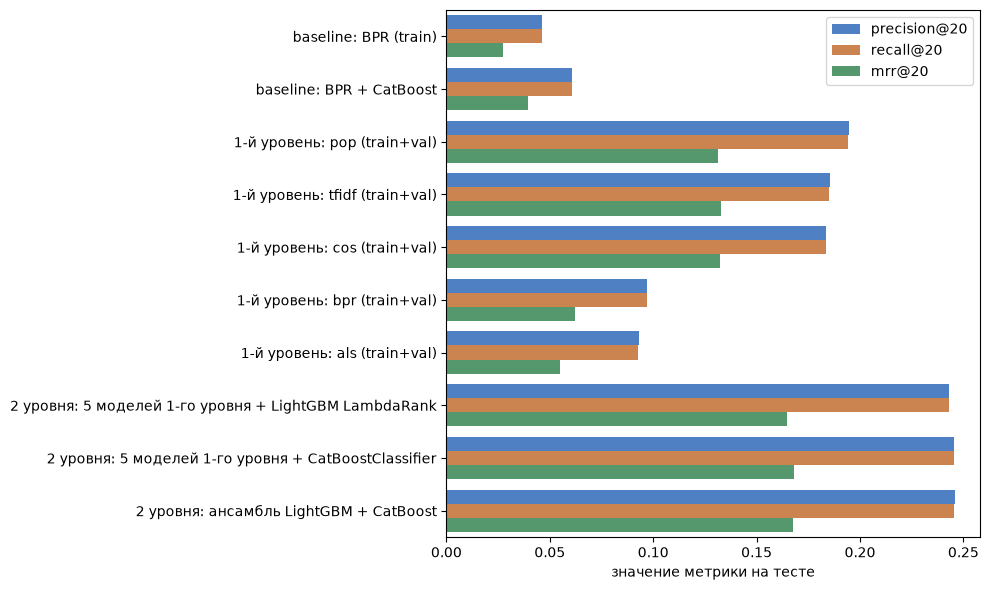

In [22]:
plot_df = summary[['precision@20', 'recall@20', 'mrr@20']].reset_index(names='модель').melt(id_vars='модель')
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, y='модель', x='value', hue='variable', palette=['#3b7dd8', '#e0803a', '#4aa36b'])
plt.xlabel('значение метрики на тесте'); plt.ylabel(''); plt.legend(title='')
plt.tight_layout()
plt.show()

## 12. Отчёт о проделанной работе

### Итог на глобальном тесте (23 195 тёплых пользователей, последние 7 дней)

| модель | precision@20 | recall@20 | mrr@20 | прирост precision@20 |
|---|---|---|---|---|
| бейзлайн с занятия: BPR (train) | 0.0464 | 0.0463 | 0.0272 | −24% |
| **бейзлайн с занятия: BPR + CatBoost** | **0.0607** | **0.0607** | **0.0396** | — |
| 1-й уровень: популярность за 7 дней | 0.1945 | 0.1944 | 0.1316 | +220% |
| 1-й уровень: item-kNN TF-IDF | 0.1853 | 0.1852 | 0.1328 | +205% |
| 1-й уровень: BPR, переобученный на train+val | 0.0969 | 0.0969 | 0.0621 | +60% |
| 2 уровня: 5 моделей + LightGBM LambdaRank | 0.2430 | 0.2429 | 0.1647 | +300% |
| 2 уровня: 5 моделей + CatBoostClassifier | 0.2454 | 0.2453 | 0.1682 | +304% |
| **2 уровня: ансамбль LightGBM + CatBoost** | **0.2457** | **0.2456** | **0.1677** | **+305%** |

Требование «улучшить precision@20 минимум на 10%» выполнено: **0.0607 → 0.2457**. Recall@20 и MRR@20 выросли так же. Бейзлайн воспроизведён (0.0607 против 0.0613; разница из-за случайности BPR и сэмплирования).

### Что реализовано
1. **Модели первого уровня.** Кроме BPR добавлены ALS, item-kNN (Cosine и TF-IDF, `implicit`) и популярность за последнюю неделю.
   Кандидаты — объединение топов (pop 100, TF-IDF 100, Cosine/BPR/ALS по 50), в среднем ~216 на пользователя. Пул покрывает 47.7%
   тестовых просмотров. Ранг и скор каждой модели, а также число предложивших айтем моделей (`n_src`) используются как признаки.
2. **Схема обучения.** Модели первого уровня обучаются на всей истории до момента предсказания. Ранкер учится на кандидатах,
   построенных по истории до начала окна меток, и на метках из этого окна; на тесте используется вся история до `test_thr`.
   Все признаки считаются строго по прошлому, утечки нет.
3. **Генерация признаков (43 признака).** Популярность айтема за 1/3/7/14/30 дней и за всё время, тренд популярности, новизна айтема,
   средний процент досмотра, активность пользователя за разные окна, давность последнего просмотра, «стаж», доля сериалов,
   жанровая близость пользователь–айтем, контентные и соцдем-признаки.
4. **Подбор разбиения и гиперпараметров** на отдельной валидационной неделе `[test_thr − 7, test_thr)`, тест в подборе не участвовал.
   Перебраны окно меток 7/14/21 день и сложность деревьев LightGBM (`num_leaves` 31–255). Выбраны окно 14 дней и `num_leaves=63`.
5. **Модели второго уровня:** LightGBM LambdaRank (оптимизирует ранжирование внутри пользователя, обучается ~2 мин),
   CatBoostClassifier (~19 мин) и их ансамбль по средним перцентильным рангам.

### Что дало наибольший прирост
* **Переобучение первого уровня на свежих данных — главный фактор.** Бейзлайн обучал BPR только на данных до середины июня
  и не видел двух месяцев перед тестом. Один только BPR, переобученный на train+val, удваивает precision (0.046 → 0.097).
* **Популярность и item-kNN как модели первого уровня.** В KION сильный эффект новинок и трендов: «топ за неделю» сам по себе даёт 0.1945,
  то есть в 3 раза лучше всего бейзлайна. Item-kNN (TF-IDF/Cosine) на бинарной матрице заметно сильнее матричных разложений (0.185 против 0.09–0.10).
* **Признаки популярности за разные временные окна.** По абляции на тесте: ранкер только на признаках первого уровня даёт 0.2183,
  добавление `i_pop*`/`i_trend` поднимает до 0.2413. Остальные признаки добавляют немного.
* **Смешивание источников ранкером.** Двухуровневая модель лучше лучшего одиночного источника на ~26% (0.2457 против 0.1945).
  Без кандидатов `pop` качество падает сильнее всего (до 0.2364), без TF-IDF — до 0.2388. Вклад Cosine, BPR и ALS мал (−0.0005…−0.0007),
  они почти дублируют сигнал TF-IDF и популярности.

### Что не сработало или сработало слабо
* **Длинное окно меток.** На валидации окна 7/14/21 дней дали 0.2397/0.2431/0.2392. Разница в пределах ~0.004, длинные окна лишь добавляют «устаревших» позитивов.
* **Усложнение деревьев** (`num_leaves` 127–255) не помогло, 31–63 оптимально.
* **Признаки пользователь×айтем** (жанровая близость, склонность к сериалам) прироста не дали. Без них на тесте получилось даже чуть
  выше (0.2464 против 0.2430), но это в пределах шума. Сигнал вкуса уже содержится в скорах item-kNN.
* **BM25Recommender** при пробных запусках оказался намного хуже TF-IDF/Cosine (precision ~0.08–0.09), поэтому в пайплайн не вошёл.
  ALS/BPR с весами `watched_pct` ≈ без весов.
* **Ансамбль LightGBM + CatBoost** дал всего +0.0003 к CatBoost. CatBoost чуть точнее LightGBM (0.2454 против 0.2430),
  но обучается в ~10 раз дольше.

### Дополнения и ограничения
* Метрика precision делит число попаданий на `min(k, |true|)`, поэтому численно почти совпадает с recall@20.
  Для сопоставимости определения сохранены, векторизованная реализация сверена с исходными функциями.
* Потолок качества задаёт полнота пула кандидатов (47.7%). Дальнейший рост вероятнее всего от расширения пула
  (больше кандидатов популярности, популярность по соцдем-сегментам, «досмотреть сериал»), а не от ранкера.
* Возможные улучшения: взвешивание взаимодействий по давности в item-kNN, отдельные кандидаты по новинкам, усреднение ранкеров
  по нескольким окнам или сидам, признаки из текстов/актёров/режиссёров.

## Выводы
1. Двухуровневая модель улучшена с **precision@20 = 0.0607 до 0.2457 (+305%)**, а также recall@20 0.0607 → 0.2456 и mrr@20 0.0396 → 0.1677.
   Цель задания (+10%) достигнута.
2. Самое важное в двухэтапной схеме — **свежесть модели первого уровня** и **правильные источники кандидатов**. Для онлайн-кинотеатра
   с сильной динамикой популярности простые модели (популярность за неделю, item-kNN) существенно сильнее BPR/ALS.
3. Второй уровень окупается: он даёт +26% к лучшему одиночному источнику, но только при наличии признаков, описывающих
   **временную динамику популярности**. Ранги и скоры первого уровня без них дают заметно меньше.
4. Окно меток для ранкера стоит согласовывать с горизонтом предсказания (7–14 дней вместо 60). Гиперпараметры и разбиение нужно подбирать
   на отдельной валидационной неделе, чтобы итоговая оценка на тесте оставалась честной.
